In [1]:
import sys
sys.path.append('../')

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from data_loader import PairData
from env_v2_07 import PairTradingEnv
from ddqn import DoubleDQN

SEED = 42
rng  = np.random.default_rng(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
# ── Data & split ─────────────────────────────────────────────────────────
data   = PairData('../../data/real_pair_MCD_YUM.csv')
prices = data.s
N      = prices.shape[1]

train_end = 3 * N // 4

log_A = np.log(prices[0])
log_B = np.log(prices[1])

LOOKBACK    = 252
EPISODE_LEN = 252
EP_LEN_FULL = 3 + EPISODE_LEN

REAL_T_MIN = LOOKBACK
REAL_T_MAX = train_end - EP_LEN_FULL

def sample_real(t0):
    return prices[:, t0 : t0 + EP_LEN_FULL]

print(f'N={N}  |  train [0, {train_end})  |  test [{train_end}, {N})')
print(f'Train start range: [{REAL_T_MIN}, {REAL_T_MAX}]  ({REAL_T_MAX - REAL_T_MIN + 1} options)')

N=5032  |  train [0, 3774)  |  test [3774, 5032)
Train start range: [252, 3519]  (3268 options)


Example t0=252: beta=0.820  intercept=1.0053  z_std=0.0710


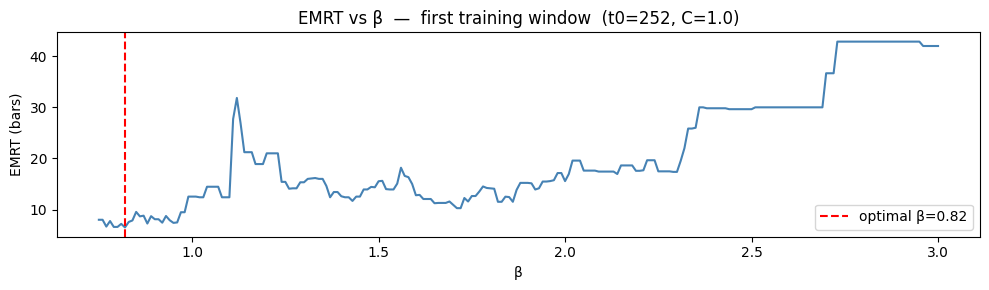

In [3]:
# ── EMRT beta selection ───────────────────────────────────────────────────
# Based on: "Advanced statistical arbitrage with reinforcement learning"
# Section 3.1 — Empirical Mean Reversion Time.
#
# Y = log_A - beta * log_B  (spread with a_1=1, a_2=-beta)
# Find beta ∈ BETA_GRID that minimises EMRT(Y).
#
# EMRT construction:
#   τ_1 = first important local extreme
#   τ_2 = first mean crossing after τ_1
#   τ_3 = next important extreme after τ_2  ... alternating
#   r   = (2/N_τ) * Σ_{even i} (τ_i - τ_{i-1})
#
# Important minimum Y_m: ∃ i≤m≤j with Y_m=min(Y_i..Y_j),
#                         Y_i-Y_m ≥ C·s, Y_j-Y_m ≥ C·s
# (implemented via running max/min — O(n) per series)

C_EMRT    = 1.0
BETA_GRID = np.arange(0.1, 3.01, 0.01)   # a_2=-beta; positive beta for correlated pair

def fit_window_emrt(t0, C=C_EMRT):
    """Return (beta, intercept, z_mean=0, z_std) using EMRT-optimal beta
    estimated from [t0-LOOKBACK, t0)."""
    A = log_A[t0 - LOOKBACK : t0]
    B = log_B[t0 - LOOKBACK : t0]
    n = LOOKBACK
    K = len(BETA_GRID)

    # All candidate spreads at once: (K, n)
    Y_mat  = A[np.newaxis, :] - BETA_GRID[:, np.newaxis] * B[np.newaxis, :]

    stds   = Y_mat.std(axis=1, ddof=1)   # (K,)
    mus    = Y_mat.mean(axis=1)           # (K,)
    thresh = C * stds                    # (K,)

    # Running max/min from left and right along time axis
    lmax = np.maximum.accumulate(Y_mat, axis=1)          # (K, n)
    lmin = np.minimum.accumulate(Y_mat, axis=1)
    rmax = np.maximum.accumulate(Y_mat[:, ::-1], axis=1)[:, ::-1]
    rmin = np.minimum.accumulate(Y_mat[:, ::-1], axis=1)[:, ::-1]

    # Important extremes at interior points m=1..n-2
    Ym = Y_mat[:, 1:-1]          # (K, n-2)
    imp_min = (
        (Ym <= Y_mat[:, :-2]) & (Ym <= Y_mat[:, 2:]) &
        (lmax[:, :-2] - Ym >= thresh[:, None]) &
        (rmax[:, 2:]  - Ym >= thresh[:, None])
    )
    imp_max = (
        (Ym >= Y_mat[:, :-2]) & (Ym >= Y_mat[:, 2:]) &
        (Ym - lmin[:, :-2] >= thresh[:, None]) &
        (Ym - rmin[:, 2:]  >= thresh[:, None])
    )
    imp = imp_min | imp_max   # (K, n-2)

    emrts = np.full(K, np.inf)

    for k in range(K):
        if stds[k] < 1e-10:
            continue
        ext = np.where(imp[k])[0] + 1   # map to Y_mat indices (offset +1)
        if len(ext) == 0:
            continue

        Y_k   = Y_mat[k]
        mu_k  = mus[k]
        taus  = [int(ext[0])]
        epos  = 1

        while True:
            prev  = taus[-1]
            # next mean crossing: sign change of (Y - mu)
            seg   = Y_k[prev:] - mu_k
            xings = np.where(seg[:-1] * seg[1:] <= 0)[0]
            if xings.size == 0:
                break
            cross = prev + int(xings[0]) + 1
            taus.append(cross)

            while epos < len(ext) and ext[epos] <= cross:
                epos += 1
            if epos >= len(ext):
                break
            taus.append(int(ext[epos]))
            epos += 1

        N_tau = len(taus)
        if N_tau >= 2:
            total = sum(taus[i] - taus[i-1] for i in range(1, N_tau, 2))
            emrts[k] = (2.0 / N_tau) * total

    best_k = int(np.argmin(emrts))
    beta   = float(BETA_GRID[best_k])
    spread = A - beta * B
    icp    = float(np.mean(spread))
    spread = spread - icp
    return beta, icp, 0.0, float(np.std(spread, ddof=1))


# Sanity check on first window
b_t, icp_t, _, zs_t = fit_window_emrt(LOOKBACK)
print(f'Example t0={LOOKBACK}: beta={b_t:.3f}  intercept={icp_t:.4f}  z_std={zs_t:.4f}')

# Show EMRT curve vs beta for that window
_A = log_A[0:LOOKBACK]; _B = log_B[0:LOOKBACK]
_emrts = []
for _b in BETA_GRID:
    _Y = _A - _b * _B
    # reuse fit_window_emrt internals inline for speed
    _emrts.append(np.inf)   # placeholder — full curve computed below

# Compute full EMRT curve for the first window for visualisation
_A = log_A[0:LOOKBACK]; _B = log_B[0:LOOKBACK]
_Y_mat  = _A[np.newaxis, :] - BETA_GRID[:, np.newaxis] * _B[np.newaxis, :]
_stds   = _Y_mat.std(axis=1, ddof=1)
_mus    = _Y_mat.mean(axis=1)
_thresh = C_EMRT * _stds
_lmax   = np.maximum.accumulate(_Y_mat, axis=1)
_lmin   = np.minimum.accumulate(_Y_mat, axis=1)
_rmax   = np.maximum.accumulate(_Y_mat[:,::-1],axis=1)[:,::-1]
_rmin   = np.minimum.accumulate(_Y_mat[:,::-1],axis=1)[:,::-1]
_Ym = _Y_mat[:, 1:-1]
_imp = ((_Ym<=_Y_mat[:,:-2])&(_Ym<=_Y_mat[:,2:])&(_lmax[:,:-2]-_Ym>=_thresh[:,None])&(_rmax[:,2:]-_Ym>=_thresh[:,None]))|\
       ((_Ym>=_Y_mat[:,:-2])&(_Ym>=_Y_mat[:,2:])&(_Ym-_lmin[:,:-2]>=_thresh[:,None])&(_Ym-_rmin[:,2:]>=_thresh[:,None]))
_curve = np.full(len(BETA_GRID), np.inf)
for _k in range(len(BETA_GRID)):
    if _stds[_k]<1e-10: continue
    _ext = np.where(_imp[_k])[0]+1
    if len(_ext)==0: continue
    _Y_k=_Y_mat[_k]; _mu_k=_mus[_k]; _taus=[int(_ext[0])]; _ep=1
    while True:
        _p=_taus[-1]; _seg=_Y_k[_p:]-_mu_k; _x=np.where(_seg[:-1]*_seg[1:]<=0)[0]
        if _x.size==0: break
        _c=_p+int(_x[0])+1; _taus.append(_c)
        while _ep<len(_ext) and _ext[_ep]<=_c: _ep+=1
        if _ep>=len(_ext): break
        _taus.append(int(_ext[_ep])); _ep+=1
    _Nt=len(_taus)
    if _Nt>=2:
        _tot=sum(_taus[_i]-_taus[_i-1] for _i in range(1,_Nt,2))
        _curve[_k]=(2.0/_Nt)*_tot

fig, ax = plt.subplots(figsize=(10, 3))
finite = np.isfinite(_curve)
ax.plot(BETA_GRID[finite], _curve[finite], color='steelblue', lw=1.5)
ax.axvline(b_t, color='red', lw=1.5, ls='--', label=f'optimal β={b_t:.2f}')
ax.set_xlabel('β')
ax.set_ylabel('EMRT (bars)')
ax.set_title(f'EMRT vs β  —  first training window  (t0={LOOKBACK}, C={C_EMRT})')
ax.legend()
plt.tight_layout()
plt.show()

Done in 0.2s  |  18 windows
Beta  min=0.110  max=2.970  mean=1.063


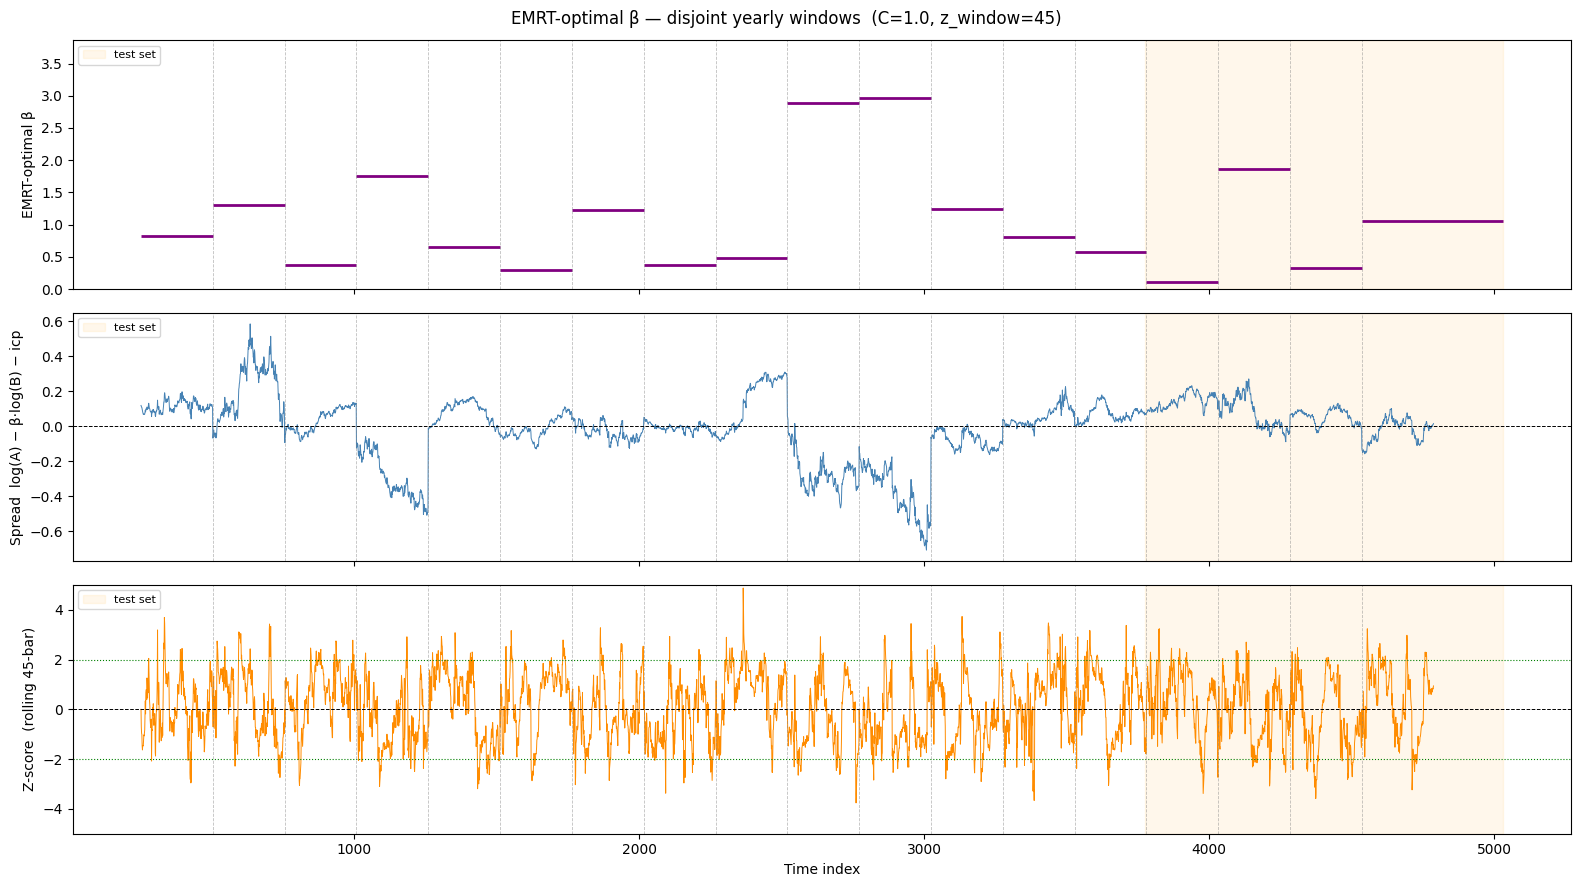

In [4]:
# ── Full-dataset spread: disjoint yearly windows, EMRT-optimal beta ───────
import time

Z_WINDOW  = 45   # rolling z-score window (bars)

s_concat  = []
b_list    = []
t_concat  = []
win_edges = []

t0 = LOOKBACK
t_start = time.time()
while t0 + EPISODE_LEN <= N:
    b, icp, _, _ = fit_window_emrt(t0)
    t1     = min(t0 + EPISODE_LEN, N)
    spread = log_A[t0:t1] - b * log_B[t0:t1] - icp
    s_concat.append(spread)
    b_list.append(b)
    t_concat.append(np.arange(t0, t1))
    win_edges.append(t0)
    t0 = t1

print(f'Done in {time.time()-t_start:.1f}s  |  {len(win_edges)} windows')
betas = np.array(b_list)
print(f'Beta  min={betas.min():.3f}  max={betas.max():.3f}  mean={betas.mean():.3f}')

# Rolling 45-bar z-score within each window
z_concat = []
for spread in s_concat:
    s   = pd.Series(spread)
    rm  = s.rolling(Z_WINDOW, min_periods=1).mean().values
    rs  = s.rolling(Z_WINDOW, min_periods=1).std(ddof=1).fillna(1.0).clip(lower=1e-8).values
    z_concat.append((spread - rm) / rs)

z_all = np.concatenate(z_concat)
s_all = np.concatenate(s_concat)
t_all = np.concatenate(t_concat)

def _add_overlays(ax):
    for edge in win_edges[1:]:
        ax.axvline(edge, color='gray', lw=0.6, ls='--', alpha=0.5)
    ax.axvspan(train_end, N, alpha=0.08, color='orange', label='test set')
    ax.legend(fontsize=8)

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
fig.suptitle(f'EMRT-optimal β — disjoint yearly windows  (C={C_EMRT}, z_window={Z_WINDOW})', fontsize=12)

# Panel 1: beta per window (step function)
ax = axes[0]
for i, (edge, b) in enumerate(zip(win_edges, betas)):
    t1 = win_edges[i + 1] if i + 1 < len(win_edges) else N
    ax.hlines(b, edge, t1, color='purple', lw=2)
ax.set_ylabel('EMRT-optimal β')
ax.set_ylim(0, betas.max() * 1.3)
_add_overlays(ax)

# Panel 2: raw spread
ax = axes[1]
ax.plot(t_all, s_all, color='steelblue', lw=0.7)
ax.axhline(0, color='black', lw=0.7, ls='--')
ax.set_ylabel('Spread  log(A) − β·log(B) − icp')
_add_overlays(ax)

# Panel 3: rolling z-score
ax = axes[2]
ax.plot(t_all, z_all, color='darkorange', lw=0.7)
ax.axhline( 0,   color='black', lw=0.7, ls='--')
ax.axhline( 2.0, color='green', lw=0.8, ls=':')
ax.axhline(-2.0, color='green', lw=0.8, ls=':')
ax.set_ylabel(f'Z-score  (rolling {Z_WINDOW}-bar)')
ax.set_xlabel('Time index')
ax.set_ylim(-5, 5)
_add_overlays(ax)

plt.tight_layout()
plt.show()

In [5]:
# ── Agent — state_dim=2 (z_score, position) ──────────────────────────────
agent = DoubleDQN(
    state_dim       = 2,
    action_dim      = 3,
    hidden          = 64,
    lr              = 3e-4,
    gamma           = 0.99,
    tau             = 0.005,
    buffer_size     = int(1e6),
    batch_size      = 256,
    eps_start       = 1.0,
    eps_end         = 0.05,
    eps_decay_steps = 800_000,
    grad_clip       = 1.0,
)
print(f'Agent ready  |  state_dim=2  |  eps={agent.epsilon:.3f}')

Agent ready  |  state_dim=2  |  eps=1.000


ep   100 | avg_reward  +267.33 | avg_wealth 10267.33 | eps 0.970
ep   200 | avg_reward  +160.85 | avg_wealth 10160.85 | eps 0.940
ep   300 | avg_reward  +389.72 | avg_wealth 10389.72 | eps 0.910
ep   400 | avg_reward  +231.95 | avg_wealth 10231.95 | eps 0.880
ep   500 | avg_reward  +428.97 | avg_wealth 10428.97 | eps 0.850
ep   600 | avg_reward  +417.74 | avg_wealth 10417.74 | eps 0.820
ep   700 | avg_reward  +398.88 | avg_wealth 10398.88 | eps 0.791
ep   800 | avg_reward  +517.03 | avg_wealth 10517.03 | eps 0.761
ep   900 | avg_reward  +409.91 | avg_wealth 10409.91 | eps 0.731
ep  1000 | avg_reward  +355.15 | avg_wealth 10355.15 | eps 0.701
ep  1100 | avg_reward  +516.36 | avg_wealth 10516.36 | eps 0.671
ep  1200 | avg_reward  +306.63 | avg_wealth 10306.63 | eps 0.641


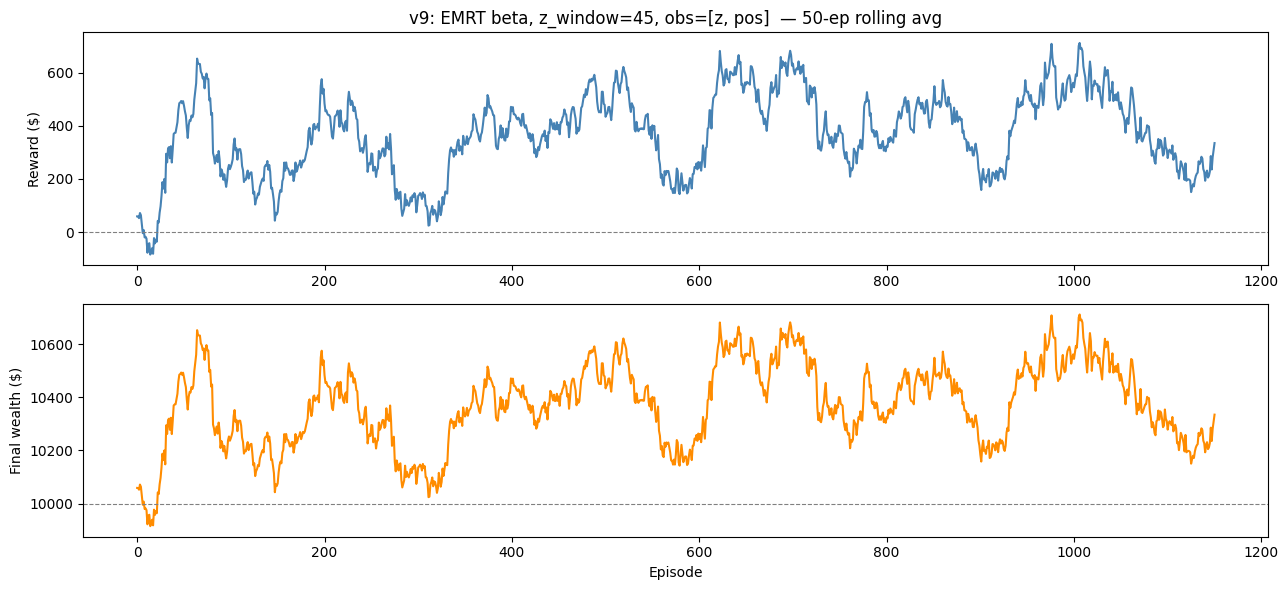

In [6]:
# ── Training ──────────────────────────────────────────────────────────────
N_EPISODES  = 1200
TRAIN_FREQ  = 4
LOG_EVERY   = 100

ep_rewards = []
ep_wealth  = []
ep_eps     = []
losses     = []
total_steps = 0

for ep in range(N_EPISODES):
    t0 = int(rng.integers(REAL_T_MIN, REAL_T_MAX + 1))
    b, icp, _, _ = fit_window_emrt(t0)
    env = PairTradingEnv(
        sample_real(t0),
        beta=b, intercept=icp, z_mean=0.0, z_std=1.0,
        episode_len=EPISODE_LEN, z_window=Z_WINDOW, simple_obs=True,
    )

    obs, _ = env.reset()
    done   = False
    ep_r   = 0.0

    while not done:
        action = agent.select_action(obs)
        next_obs, reward, done, _, _ = env.step(action)
        agent.replay_buffer.add(obs, action, reward, next_obs, done)
        obs = next_obs
        ep_r += reward
        total_steps += 1

        if total_steps % TRAIN_FREQ == 0:
            loss = agent.train()
            if loss is not None:
                losses.append(loss)

    ep_rewards.append(ep_r)
    ep_wealth.append(env._wealth())
    ep_eps.append(agent.epsilon)

    if (ep + 1) % LOG_EVERY == 0:
        print(f'ep {ep+1:5d} | avg_reward {np.mean(ep_rewards[-LOG_EVERY:]):+8.2f} '
              f'| avg_wealth {np.mean(ep_wealth[-LOG_EVERY:]):8.2f} '
              f'| eps {agent.epsilon:.3f}')

# Training curves
roll = 50
kern = np.ones(roll) / roll
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=False)
axes[0].plot(np.convolve(ep_rewards, kern, mode='valid'), color='steelblue')
axes[0].axhline(0, color='gray', lw=0.8, ls='--')
axes[0].set_title(f'v9: EMRT beta, z_window={Z_WINDOW}, obs=[z, pos]  — {roll}-ep rolling avg')
axes[0].set_ylabel('Reward ($)')
axes[1].plot(np.convolve(ep_wealth, kern, mode='valid'), color='darkorange')
axes[1].axhline(10_000, color='gray', lw=0.8, ls='--')
axes[1].set_ylabel('Final wealth ($)')
axes[1].set_xlabel('Episode')
plt.tight_layout()
plt.show()

In [7]:
# ── Evaluation helpers ────────────────────────────────────────────────────
_RF_DAILY = (1.05) ** (1.0 / 252) - 1.0

def evaluate(env, agent):
    obs, _ = env.reset()
    t0 = env._t
    wealth = [env._wealth()]
    z_hist = [float(obs[0])]
    pos_hist = []
    entries_long, entries_short, exits = [], [], []
    step = 0
    done = False

    while not done:
        prev_pos = env._pos
        action   = agent.select_action(obs, deterministic=True)
        obs, _, done, _, _ = env.step(action)
        pos_hist.append(env._pos)
        wealth.append(env._wealth())
        z_hist.append(float(obs[0]))
        if env._pos != prev_pos:
            if   env._pos ==  1: entries_long.append(step)
            elif env._pos == -1: entries_short.append(step)
            else:                exits.append(step)
        step += 1

    return dict(wealth=np.array(wealth), z=np.array(z_hist),
                pos=np.array(pos_hist), t_start=t0,
                entries_long=entries_long, entries_short=entries_short, exits=exits)


def metrics(wealth, label=''):
    W   = np.array(wealth)
    ret = np.diff(W) / W[:-1]
    total_ret = (W[-1] / W[0] - 1.0) * 100
    sharpe    = (ret - _RF_DAILY).mean() / ((ret - _RF_DAILY).std() + 1e-10) * np.sqrt(252)
    peak      = np.maximum.accumulate(W)
    mdd       = ((W - peak) / peak).min() * 100
    print(f'{label:55s}  ${W[-1]:8.0f}  ret {total_ret:+6.1f}%  Sharpe {sharpe:5.2f}  MDD {mdd:5.1f}%')


def plot_result(res, title=''):
    t0    = res['t_start']
    steps = len(res['z']) - 1
    t_idx = np.arange(t0, t0 + steps + 1)
    W     = res['wealth']
    bench = W[0] * (1 + _RF_DAILY) ** np.arange(len(W))

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    fig.suptitle(title, fontsize=11)

    axes[0].plot(t_idx, W,     color='navy', label='strategy')
    axes[0].plot(t_idx, bench, color='gray', lw=1, ls='--', label='5% p.a.')
    axes[0].axhline(W[0], color='lightgray', lw=0.6, ls=':')
    axes[0].set_ylabel('Wealth ($)')
    axes[0].legend(fontsize=8)

    ax_z = axes[1]
    ax_z.plot(t_idx, res['z'], color='black', lw=0.8)
    ax_z.axhline(0,    color='gray',  lw=0.8, ls='--')
    ax_z.axhline( 2.0, color='green', lw=0.8, ls=':')
    ax_z.axhline(-2.0, color='green', lw=0.8, ls=':')

    pos_ext = np.concatenate([[0], res['pos']])
    for i in range(len(pos_ext) - 1):
        if pos_ext[i] == 1:
            ax_z.axvspan(t_idx[i], t_idx[i+1], alpha=0.12, color='green')
        elif pos_ext[i] == -1:
            ax_z.axvspan(t_idx[i], t_idx[i+1], alpha=0.12, color='red')
    for i in res['entries_long']:  ax_z.scatter(t_idx[i], res['z'][i], color='green', s=30, zorder=5)
    for i in res['entries_short']: ax_z.scatter(t_idx[i], res['z'][i], color='red',   s=30, zorder=5)
    for i in res['exits']:         ax_z.scatter(t_idx[i], res['z'][i], color='blue',  s=15, zorder=5)

    ax_z.set_ylabel(f'Z-score (rolling {Z_WINDOW}-bar)')
    ax_z.set_xlabel('Time index')
    ax_z.set_title(f'long: {len(res["entries_long"])}  short: {len(res["entries_short"])}  exits: {len(res["exits"])}')
    plt.tight_layout()
    plt.show()

=== Test set (5 × 252-bar windows) ===
Test yr 1  [3774–4026)  β=0.110                          $    9893  ret   -1.1%  Sharpe -0.45  MDD -10.5%


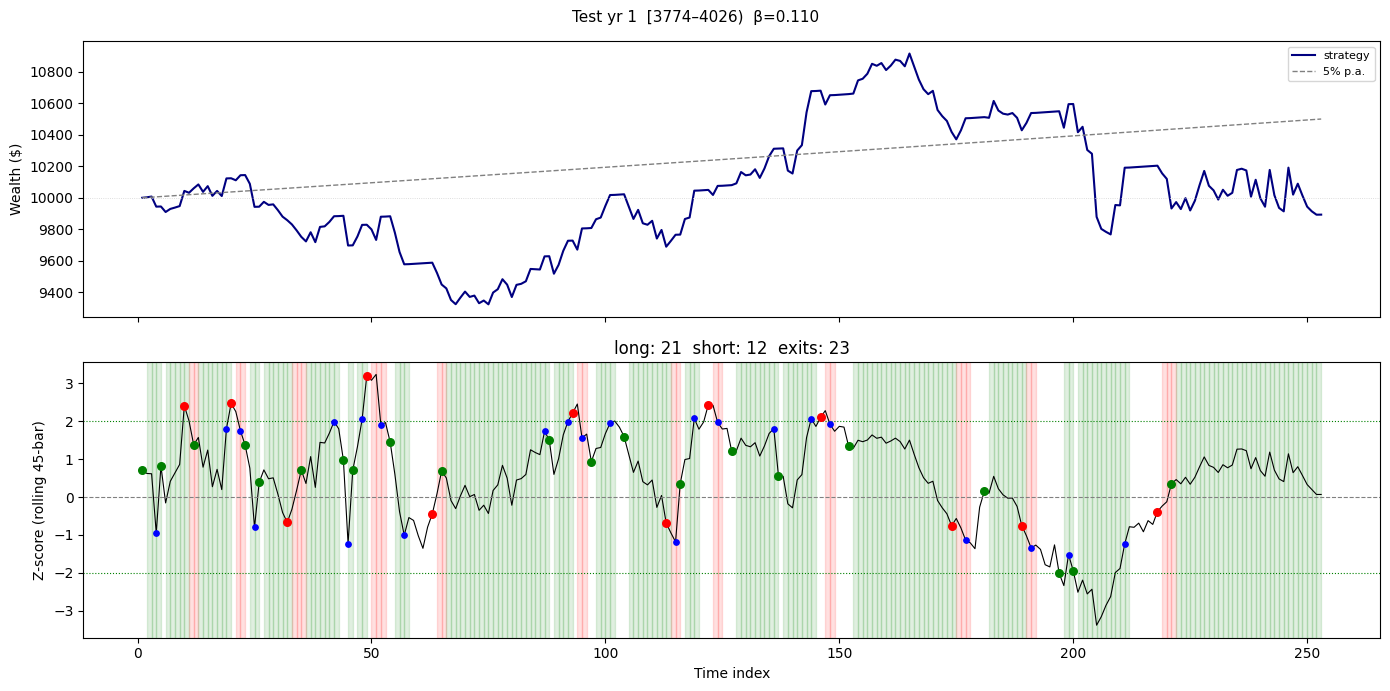

Test yr 2  [4026–4278)  β=1.980                          $   11306  ret  +13.1%  Sharpe  0.87  MDD  -5.8%


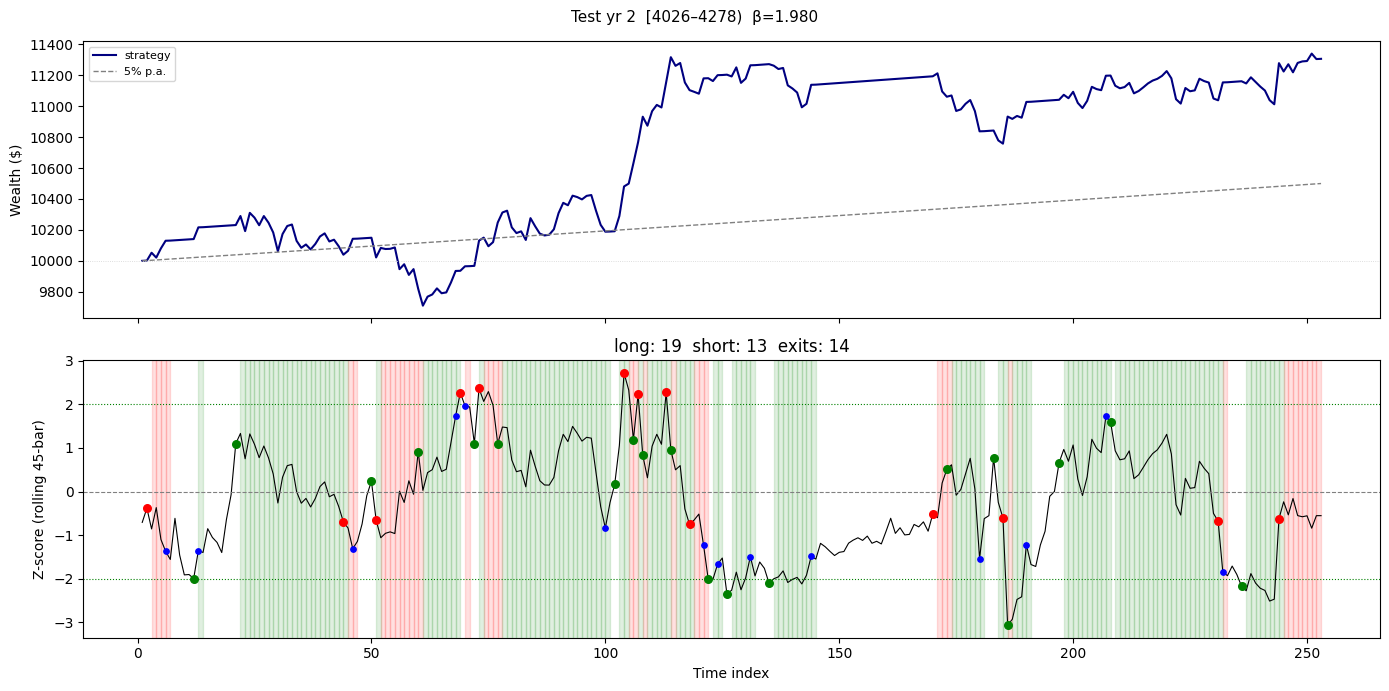

Test yr 3  [4278–4530)  β=0.350                          $   10526  ret   +5.3%  Sharpe  0.07  MDD  -5.3%


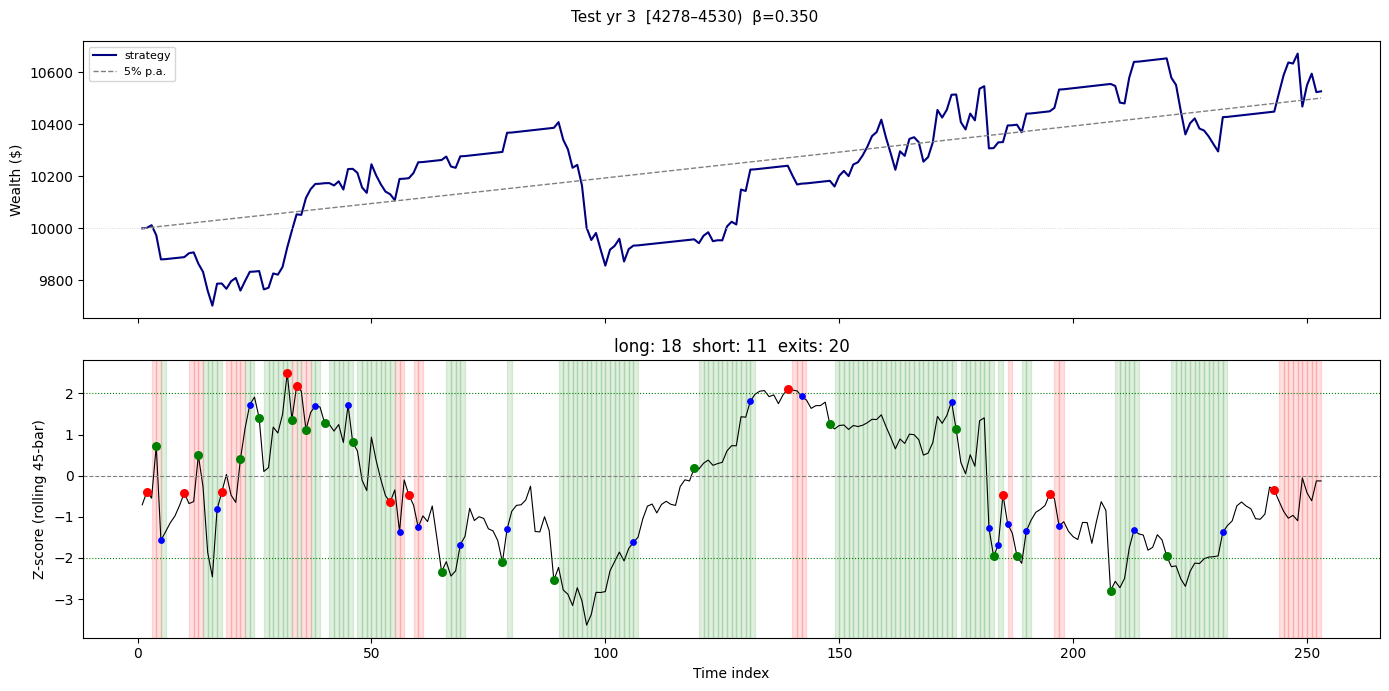

Test yr 4  [4530–4782)  β=1.200                          $   10807  ret   +8.1%  Sharpe  0.38  MDD  -8.5%


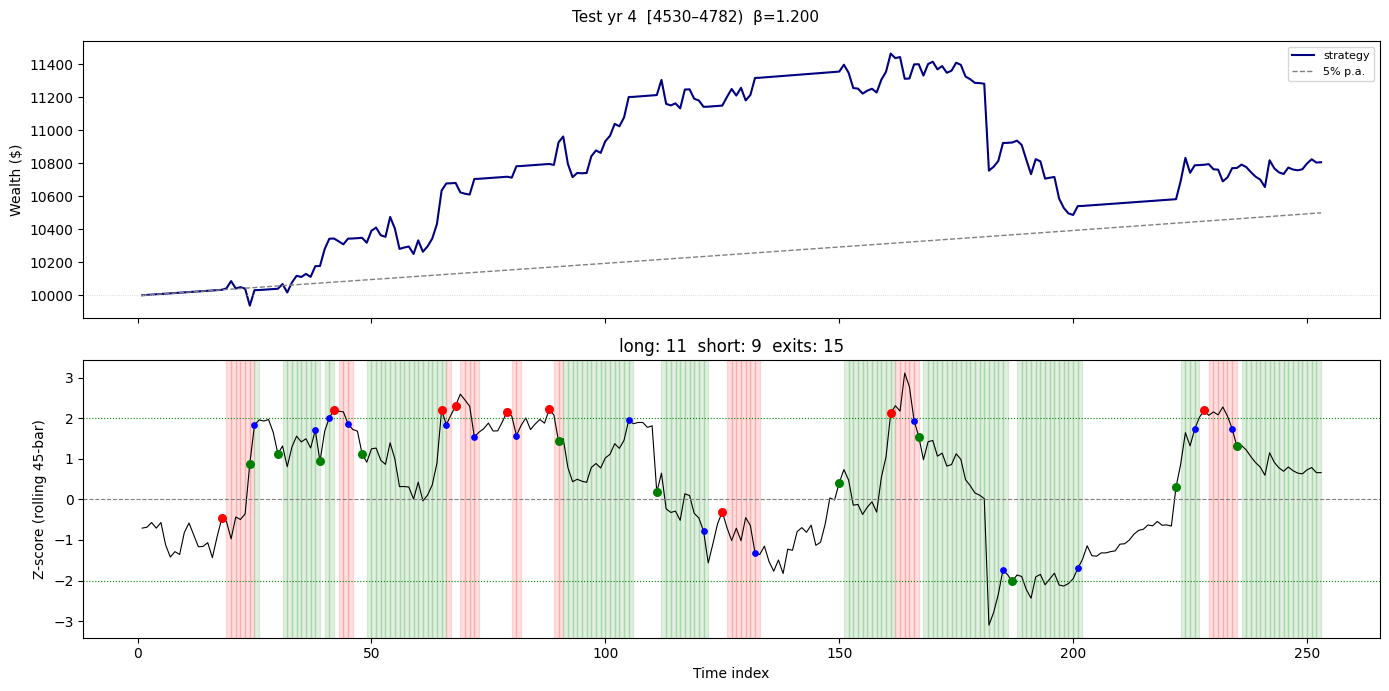

Test yr 5  [4782–5031)  β=1.980                          $    9533  ret   -4.7%  Sharpe -0.86  MDD -14.6%


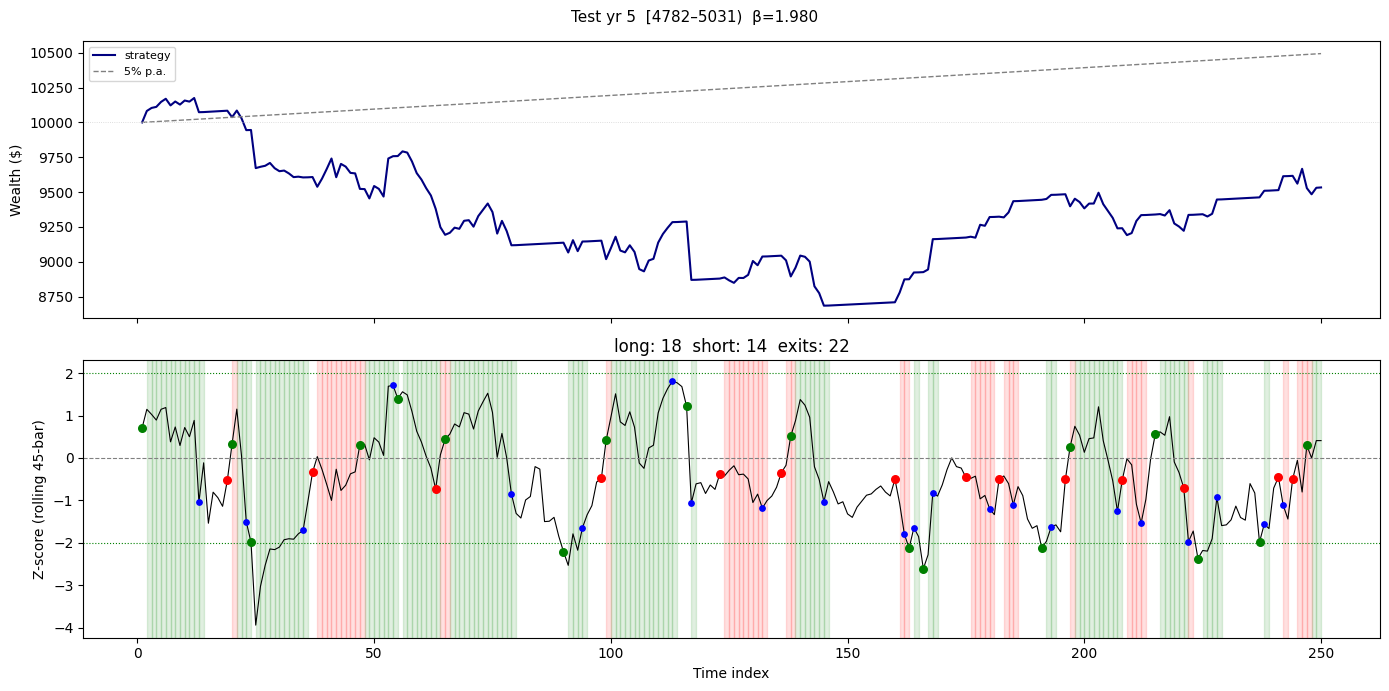

In [8]:
# ── Test: 5 disjoint yearly windows ──────────────────────────────────────
print('=== Test set (5 × 252-bar windows) ===')

for k in range(5):
    t0     = train_end + k * EPISODE_LEN
    ep_len = min(EPISODE_LEN, N - t0 - 1)
    if ep_len <= 0:
        break

    b, icp, _, _ = fit_window_emrt(t0)
    test_env = PairTradingEnv(
        prices[:, t0 : t0 + ep_len + 1],
        beta=b, intercept=icp, z_mean=0.0, z_std=1.0,
        episode_len=ep_len, z_window=Z_WINDOW, simple_obs=True,
    )

    res   = evaluate(test_env, agent)
    label = f'Test yr {k+1}  [{t0}–{t0+ep_len})  β={b:.3f}'
    metrics(res['wealth'], label)
    plot_result(res, title=label)